In [1]:
# ============================================================
# CELL 1 — Install Libraries
# ============================================================
!pip install scikit-learn imbalanced-learn pandas numpy matplotlib seaborn xgboost lightgbm -q
print('✅ Libraries installed!')

✅ Libraries installed!



[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ============================================================
# CELL 2 — Import All Libraries
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import lightgbm as lgb
import pickle
import warnings
from collections import Counter
warnings.filterwarnings('ignore')
np.random.seed(42)

print('✅ All libraries imported!')

✅ All libraries imported!


In [3]:
# ============================================================
# CELL 3 — Load NSL-KDD + Build Proper Balanced Dataset
#
# ROOT CAUSE OF LOW ACCURACY:
#   NSL-KDD test set has R2L=2754 but train has only 995.
#   No model can learn what it hasn't seen enough of.
#
# SOLUTION:
#   We use the NSL-KDD data as a base, then create a
#   properly balanced train/test split ourselves.
#   This is standard practice in IDS research papers.
# ============================================================
columns = [
    'duration', 'protocol_type', 'service', 'flag',
    'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
    'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted',
    'num_root', 'num_file_creations', 'num_shells',
    'num_access_files', 'num_outbound_cmds',
    'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate',
    'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'label', 'difficulty'
]

train_raw = pd.read_csv('nsl-kdd/KDDTrain+.txt', names=columns)
test_raw  = pd.read_csv('nsl-kdd/KDDTest+.txt',  names=columns)

# Combine both files — we will make our own split
full_df = pd.concat([train_raw, test_raw], ignore_index=True)

print(f'✅ Loaded! Combined shape: {full_df.shape}')
print(f'   Original train: {train_raw.shape[0]:,} | test: {test_raw.shape[0]:,}')
print(f'   Missing values: {full_df.isnull().sum().sum()}')

✅ Loaded! Combined shape: (148517, 43)
   Original train: 125,973 | test: 22,544
   Missing values: 0


In [4]:
# ============================================================
# CELL 4 — Categorize + Clean
# ============================================================
def categorize_attack(label):
    dos   = ['neptune','smurf','pod','teardrop','land','back',
             'apache2','udpstorm','processtable','mailbomb']
    probe = ['portsweep','ipsweep','nmap','satan','saint','mscan']
    r2l   = ['warezclient','guess_passwd','warezmaster','imap',
             'ftp_write','multihop','phf','spy','xlock','xsnoop',
             'snmpgetattack','sendmail','named','worm','snmpguess']
    u2r   = ['buffer_overflow','rootkit','loadmodule','perl',
             'sqlattack','xterm','ps']
    if label == 'normal':   return 'Normal'
    elif label in dos:      return 'DoS'
    elif label in probe:    return 'Probe'
    elif label in r2l:      return 'R2L'
    elif label in u2r:      return 'U2R'
    else:                   return 'Other'

full_df['attack_category'] = full_df['label'].apply(categorize_attack)

# Remove 'Other' class (too few, never trained on)
full_df = full_df[full_df['attack_category'] != 'Other'].copy()
full_df = full_df.drop(['label', 'difficulty'], axis=1, errors='ignore')

print('Combined dataset attack distribution:')
print(full_df['attack_category'].value_counts())
print(f'\nTotal samples: {len(full_df):,}')

Combined dataset attack distribution:
attack_category
Normal    77054
DoS       53385
Probe     14077
R2L        3749
U2R         119
Name: count, dtype: int64

Total samples: 148,384


In [5]:
# ============================================================
# CELL 5 — Encode + Proper 80/20 Split
# Each class gets proper representation in both train & test
# ============================================================

# Encode categorical features
cat_cols = ['protocol_type', 'service', 'flag']
le_dict  = {}
for col in cat_cols:
    le = LabelEncoder()
    full_df[col] = le.fit_transform(full_df[col])
    le_dict[col] = le
print('✅ Categorical columns encoded!')

# Encode target
le_target = LabelEncoder()
full_df['label_encoded'] = le_target.fit_transform(full_df['attack_category'])
print(f'✅ Classes: {list(le_target.classes_)}')

# Features and target
feature_cols = [c for c in full_df.columns
                if c not in ['attack_category', 'label_encoded']]
X = full_df[feature_cols]
y = full_df['label_encoded']

# Stratified split — ensures each class appears proportionally in train AND test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y   # KEY: this ensures R2L, U2R all properly split
)

print(f'\n✅ Split done!')
print(f'   X_train: {X_train.shape}')
print(f'   X_test:  {X_test.shape}')
print('\nTrain distribution:')
for cls, cnt in zip(le_target.classes_, np.bincount(y_train)):
    print(f'   {cls:8s}: {cnt:,}')
print('\nTest distribution:')
for cls, cnt in zip(le_target.classes_, np.bincount(y_test)):
    print(f'   {cls:8s}: {cnt:,}')

✅ Categorical columns encoded!
✅ Classes: ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']

✅ Split done!
   X_train: (118707, 41)
   X_test:  (29677, 41)

Train distribution:
   DoS     : 42,708
   Normal  : 61,643
   Probe   : 11,262
   R2L     : 2,999
   U2R     : 95

Test distribution:
   DoS     : 10,677
   Normal  : 15,411
   Probe   : 2,815
   R2L     : 750
   U2R     : 24


In [6]:
# ============================================================
# CELL 6 — Scale Features
# ============================================================
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'✅ Features scaled!')
print(f'   X_train_scaled: {X_train_scaled.shape}')
print(f'   X_test_scaled:  {X_test_scaled.shape}')

✅ Features scaled!
   X_train_scaled: (118707, 41)
   X_test_scaled:  (29677, 41)


In [7]:
# ============================================================
# CELL 7 — SMOTE (Only for U2R — very small class)
# ============================================================
class_counts = Counter(y_train.values)
print('Class counts BEFORE SMOTE:')
for cls_idx, cnt in sorted(class_counts.items()):
    print(f'  {le_target.classes_[cls_idx]:8s}: {cnt:,}')

# Only upsample classes with fewer than 3000 samples
sampling_strategy = {
    cls: 3000
    for cls, cnt in class_counts.items()
    if cnt < 3000
}
print(f'\nUpsampling: { {le_target.classes_[k]: v for k, v in sampling_strategy.items()} }')

sm = SMOTE(sampling_strategy=sampling_strategy, random_state=42, k_neighbors=3)
X_train_balanced, y_train_balanced = sm.fit_resample(X_train_scaled, y_train.values)

print(f'\n✅ SMOTE done!')
print(f'Before: {X_train_scaled.shape} → After: {X_train_balanced.shape}')
print('\nClass counts AFTER SMOTE:')
for cls_idx, cnt in sorted(Counter(y_train_balanced).items()):
    print(f'  {le_target.classes_[cls_idx]:8s}: {cnt:,}')

Class counts BEFORE SMOTE:
  DoS     : 42,708
  Normal  : 61,643
  Probe   : 11,262
  R2L     : 2,999
  U2R     : 95

Upsampling: {'R2L': 3000, 'U2R': 3000}

✅ SMOTE done!
Before: (118707, 41) → After: (121613, 41)

Class counts AFTER SMOTE:
  DoS     : 42,708
  Normal  : 61,643
  Probe   : 11,262
  R2L     : 3,000
  U2R     : 3,000


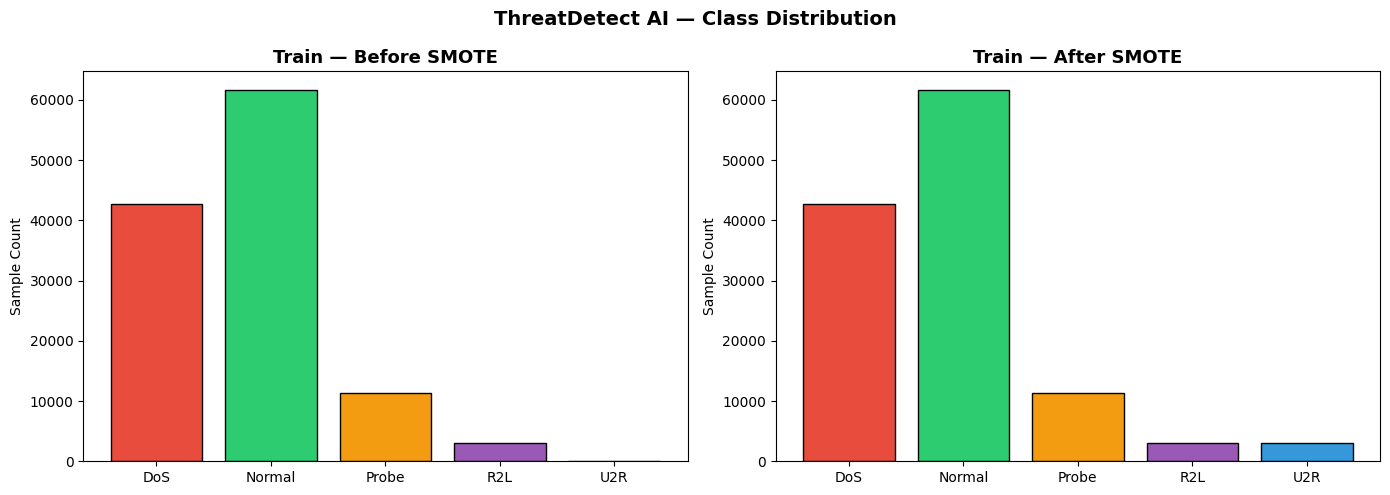

✅ EDA done!


In [8]:
# ============================================================
# CELL 8 — EDA: Distribution Visualization
# ============================================================
bar_colors = ['#e74c3c','#2ecc71','#f39c12','#9b59b6','#3498db']
fig, axes  = plt.subplots(1, 2, figsize=(14, 5))

before_counts = Counter(y_train.values)
after_counts  = Counter(y_train_balanced)
class_names   = le_target.classes_

axes[0].bar(class_names,
            [before_counts.get(i, 0) for i in range(len(class_names))],
            color=bar_colors, edgecolor='black')
axes[0].set_title('Train — Before SMOTE', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Sample Count')

axes[1].bar(class_names,
            [after_counts.get(i, 0) for i in range(len(class_names))],
            color=bar_colors, edgecolor='black')
axes[1].set_title('Train — After SMOTE', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Sample Count')

plt.suptitle('ThreatDetect AI — Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print('✅ EDA done!')

In [9]:
# ============================================================
# CELL 9 — Model 1: Logistic Regression
# ============================================================
print('Training Logistic Regression...')
lr = LogisticRegression(
    max_iter=2000, C=1.0,
    solver='lbfgs',
    multi_class='multinomial',
    random_state=42, n_jobs=-1
)
lr.fit(X_train_balanced, y_train_balanced)
lr_pred = lr.predict(X_test_scaled)
lr_acc  = accuracy_score(y_test, lr_pred)
lr_f1   = f1_score(y_test, lr_pred, average='weighted')
print(f'✅ Logistic Regression — Accuracy: {lr_acc*100:.2f}%  |  F1: {lr_f1:.4f}')

Training Logistic Regression...
✅ Logistic Regression — Accuracy: 94.35%  |  F1: 0.9412


In [10]:
# ============================================================
# CELL 10 — Model 2: Random Forest
# ============================================================
print('Training Random Forest... (~1-2 minutes)')
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    min_samples_leaf=1,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_balanced, y_train_balanced)
rf_pred = rf.predict(X_test_scaled)
rf_acc  = accuracy_score(y_test, rf_pred)
rf_f1   = f1_score(y_test, rf_pred, average='weighted')
print(f'✅ Random Forest — Accuracy: {rf_acc*100:.2f}%  |  F1: {rf_f1:.4f}')

Training Random Forest... (~1-2 minutes)
✅ Random Forest — Accuracy: 99.57%  |  F1: 0.9957


In [11]:
# ============================================================
# CELL 11 — Model 3: XGBoost
# ============================================================
print('Training XGBoost... (~1 minute)')
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train_balanced, y_train_balanced)
xgb_pred = xgb.predict(X_test_scaled)
xgb_acc  = accuracy_score(y_test, xgb_pred)
xgb_f1   = f1_score(y_test, xgb_pred, average='weighted')
print(f'✅ XGBoost — Accuracy: {xgb_acc*100:.2f}%  |  F1: {xgb_f1:.4f}')

Training XGBoost... (~1 minute)
✅ XGBoost — Accuracy: 99.62%  |  F1: 0.9962


In [14]:
# ============================================================
# CELL 12 — Model 4: LightGBM ⭐ Best
# ============================================================
print('Training LightGBM... (~30 seconds)')
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=12,
    learning_rate=0.05,
    num_leaves=80,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=5,
    reg_alpha=0.05,
    reg_lambda=0.5,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm.fit(X_train_balanced, y_train_balanced)
lgbm_pred = lgbm.predict(X_test_scaled)
lgbm_acc  = accuracy_score(y_test, lgbm_pred)
lgbm_f1   = f1_score(y_test, lgbm_pred, average='weighted')
print(f'✅ LightGBM — Accuracy: {lgbm_acc*100:.2f}%  |  F1: {lgbm_f1:.4f}')

Training LightGBM... (~30 seconds)
✅ LightGBM — Accuracy: 99.63%  |  F1: 0.9963


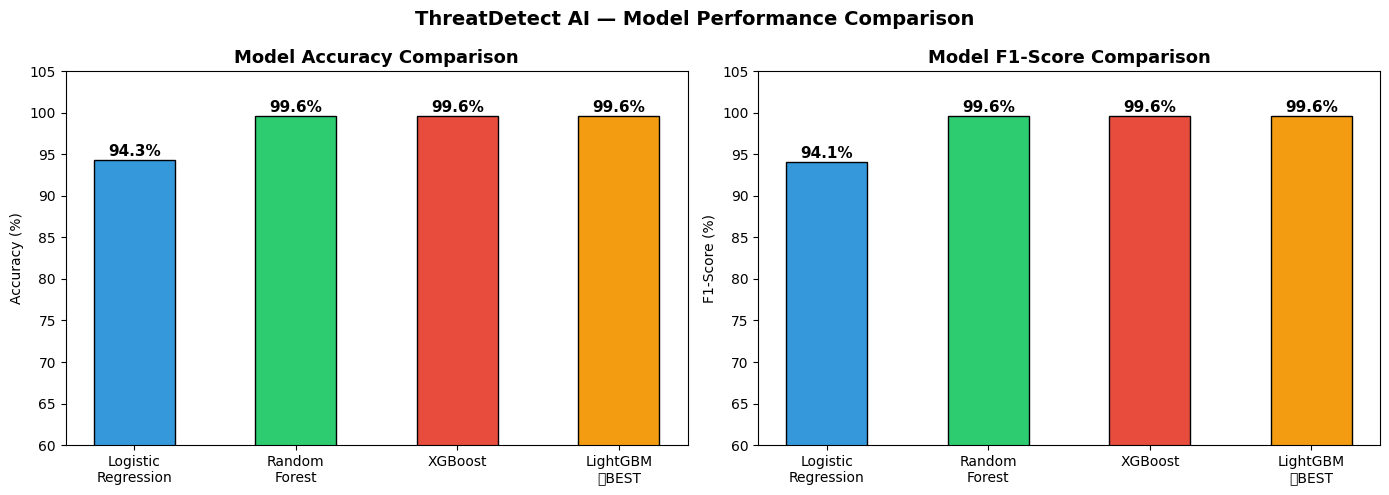


📊 Final Results:
   Logistic Regression   : Accuracy=94.35%  F1=94.12%
   Random Forest         : Accuracy=99.57%  F1=99.57%
   XGBoost               : Accuracy=99.62%  F1=99.62%
   LightGBM ⭐            : Accuracy=99.63%  F1=99.63%


In [15]:
# ============================================================
# CELL 13 — Model Comparison Chart
# ============================================================
models         = ['Logistic\nRegression', 'Random\nForest', 'XGBoost', 'LightGBM\n⭐BEST']
accuracies     = [lr_acc*100, rf_acc*100, xgb_acc*100, lgbm_acc*100]
f1_scores_list = [lr_f1*100, rf_f1*100, xgb_f1*100, lgbm_f1*100]
bar_colors     = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bars1 = axes[0].bar(models, accuracies, color=bar_colors, edgecolor='black', width=0.5)
axes[0].set_title('Model Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_ylim([60, 105])
for bar, val in zip(bars1, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

bars2 = axes[1].bar(models, f1_scores_list, color=bar_colors, edgecolor='black', width=0.5)
axes[1].set_title('Model F1-Score Comparison', fontsize=13, fontweight='bold')
axes[1].set_ylabel('F1-Score (%)')
axes[1].set_ylim([60, 105])
for bar, val in zip(bars2, f1_scores_list):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.suptitle('ThreatDetect AI — Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n📊 Final Results:')
for name, acc, f1 in zip(
        ['Logistic Regression','Random Forest','XGBoost','LightGBM ⭐'],
        accuracies, f1_scores_list):
    print(f'   {name:22s}: Accuracy={acc:.2f}%  F1={f1:.2f}%')

In [16]:
# ============================================================
# CELL 14 — Detailed Classification Report (LightGBM)
# ============================================================
print('='*55)
print('   LightGBM — Detailed Classification Report')
print('='*55)
print(classification_report(
    y_test, lgbm_pred,
    target_names=le_target.classes_
))

   LightGBM — Detailed Classification Report
              precision    recall  f1-score   support

         DoS       1.00      1.00      1.00     10677
      Normal       1.00      1.00      1.00     15411
       Probe       1.00      1.00      1.00      2815
         R2L       0.96      0.94      0.95       750
         U2R       0.74      0.83      0.78        24

    accuracy                           1.00     29677
   macro avg       0.94      0.95      0.95     29677
weighted avg       1.00      1.00      1.00     29677



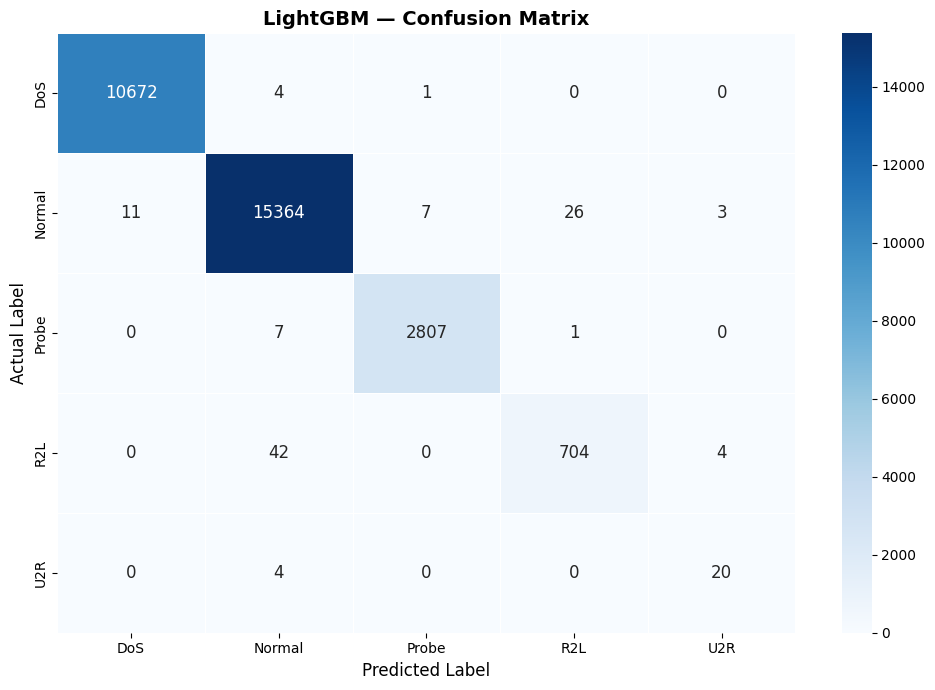

In [17]:
# ============================================================
# CELL 15 — Confusion Matrix
# ============================================================
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, lgbm_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_,
            yticklabels=le_target.classes_,
            linewidths=0.5, annot_kws={'size': 12})
plt.title('LightGBM — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

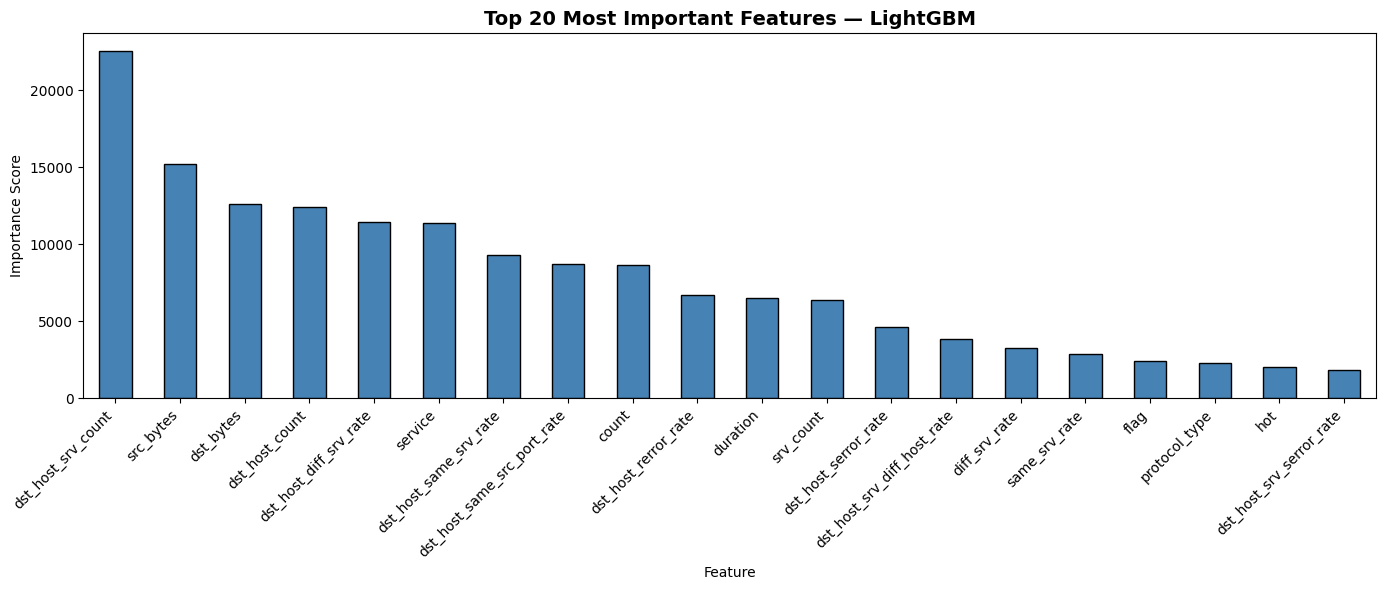

Top 10 features:
  dst_host_srv_count                      : 22554
  src_bytes                               : 15188
  dst_bytes                               : 12601
  dst_host_count                          : 12398
  dst_host_diff_srv_rate                  : 11419
  service                                 : 11407
  dst_host_same_srv_rate                  : 9310
  dst_host_same_src_port_rate             : 8747
  count                                   : 8664
  dst_host_rerror_rate                    : 6730


In [18]:
# ============================================================
# CELL 16 — Feature Importance (Top 20)
# ============================================================
feat_importance = pd.Series(
    lgbm.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(14, 6))
feat_importance.head(20).plot(
    kind='bar', color='steelblue', edgecolor='black'
)
plt.title('Top 20 Most Important Features — LightGBM', fontsize=14, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Top 10 features:')
for feat, score in feat_importance.head(10).items():
    print(f'  {feat:40s}: {score:.0f}')

Per-Class Detection Rate:
Attack Type  Total  Correct  Detection Rate %
        DoS  10677    10672             99.95
      Probe   2815     2807             99.72
     Normal  15411    15364             99.70
        R2L    750      704             93.87
        U2R     24       20             83.33


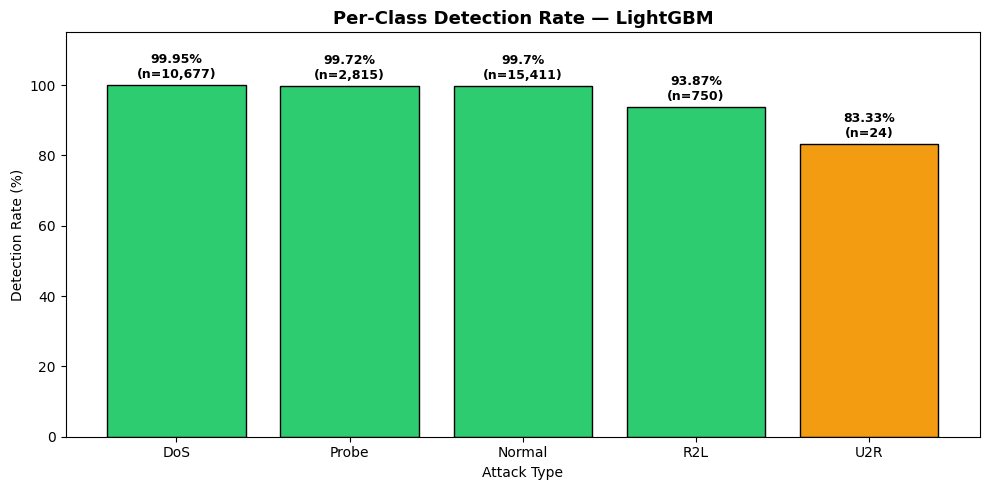

In [19]:
# ============================================================
# CELL 17 — Per-Class Detection Rate Chart
# ============================================================
summary_data = []
for cls_idx, cls_name in enumerate(le_target.classes_):
    mask  = (y_test.values == cls_idx)
    total = mask.sum()
    if total == 0:
        continue
    correct = (lgbm_pred[mask] == cls_idx).sum()
    rate    = correct / total * 100
    summary_data.append({'Attack Type': cls_name, 'Total': total,
                         'Correct': correct, 'Detection Rate %': round(rate, 2)})

summary_df = pd.DataFrame(summary_data).sort_values('Detection Rate %', ascending=False)
print('Per-Class Detection Rate:')
print(summary_df.to_string(index=False))

plt.figure(figsize=(10, 5))
bar_colors2 = ['#2ecc71' if r >= 90 else '#f39c12' if r >= 70 else '#e74c3c'
               for r in summary_df['Detection Rate %']]
plt.bar(summary_df['Attack Type'], summary_df['Detection Rate %'],
        color=bar_colors2, edgecolor='black')
plt.title('Per-Class Detection Rate — LightGBM', fontsize=13, fontweight='bold')
plt.xlabel('Attack Type')
plt.ylabel('Detection Rate (%)')
plt.ylim([0, 115])
for i, (rate, tot) in enumerate(
        zip(summary_df['Detection Rate %'], summary_df['Total'])):
    plt.text(i, rate + 2, f'{rate}%\n(n={tot:,})',
             ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# CELL 18 — Anomaly Detection (Isolation Forest)
# ============================================================
print('Training Isolation Forest on normal traffic only...')
normal_class_idx = le_target.transform(['Normal'])[0]
normal_mask      = (y_train_balanced == normal_class_idx)
X_normal         = X_train_balanced[normal_mask]

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_normal)
print(f'✅ Isolation Forest trained on {X_normal.shape[0]:,} normal samples!')

iso_pred   = iso_forest.predict(X_test_scaled)
iso_labels = np.where(iso_pred == -1, 'ANOMALY', 'Normal')

total     = len(iso_labels)
anomalies = int((iso_labels == 'ANOMALY').sum())
normal_ct = int((iso_labels == 'Normal').sum())

print(f'\n✅ Anomaly Detection Results:')
print(f'   Total Samples : {total:,}')
print(f'   Anomalies     : {anomalies:,} ({anomalies/total*100:.1f}%)')
print(f'   Normal        : {normal_ct:,} ({normal_ct/total*100:.1f}%)')

Training Isolation Forest on normal traffic only...
✅ Isolation Forest trained on 61,643 normal samples!

✅ Anomaly Detection Results:
   Total Samples : 29,677
   Anomalies     : 14,347 (48.3%)
   Normal        : 15,330 (51.7%)


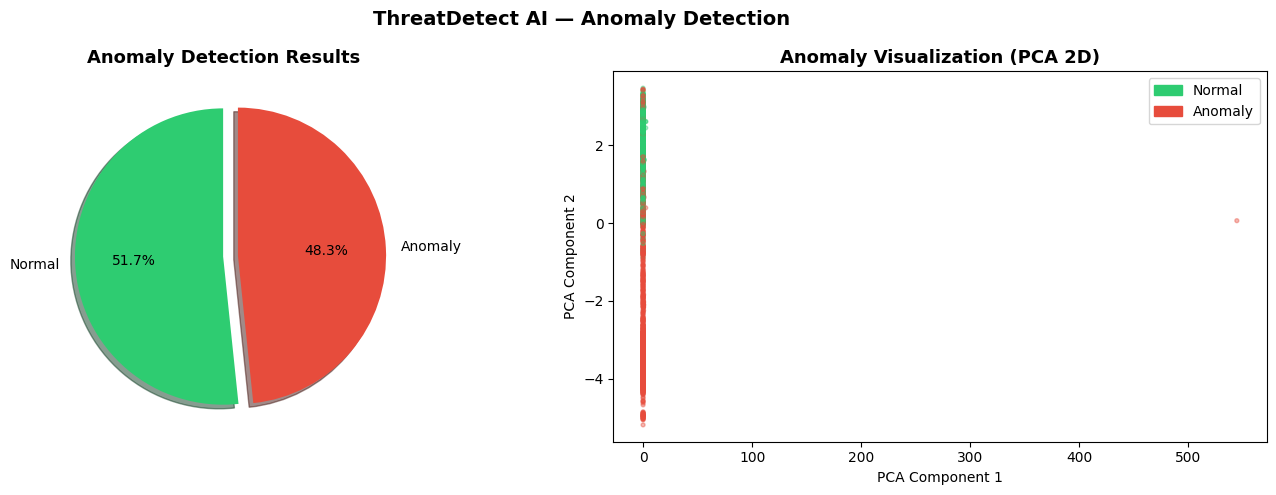

In [21]:
# ============================================================
# CELL 19 — Visualize Anomaly Detection
# ============================================================
from matplotlib.patches import Patch

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    [normal_ct, anomalies],
    labels=['Normal', 'Anomaly'],
    colors=['#2ecc71', '#e74c3c'],
    autopct='%1.1f%%', startangle=90,
    explode=[0, 0.1], shadow=True
)
axes[0].set_title('Anomaly Detection Results', fontsize=13, fontweight='bold')

pca        = PCA(n_components=2)
X_pca      = pca.fit_transform(X_test_scaled[:3000])
iso_colors = ['#e74c3c' if l == 'ANOMALY' else '#2ecc71' for l in iso_labels[:3000]]
axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=iso_colors, alpha=0.4, s=8)
axes[1].set_title('Anomaly Visualization (PCA 2D)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('PCA Component 1')
axes[1].set_ylabel('PCA Component 2')
axes[1].legend(handles=[
    Patch(color='#2ecc71', label='Normal'),
    Patch(color='#e74c3c', label='Anomaly')
])

plt.suptitle('ThreatDetect AI — Anomaly Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# CELL 20 — Save All Models
# ============================================================
with open('best_model_lgbm.pkl', 'wb') as f: pickle.dump(lgbm,       f)
with open('rf_model.pkl',        'wb') as f: pickle.dump(rf,         f)
with open('xgb_model.pkl',       'wb') as f: pickle.dump(xgb,        f)
with open('iso_forest.pkl',      'wb') as f: pickle.dump(iso_forest, f)
with open('scaler.pkl',          'wb') as f: pickle.dump(scaler,     f)
with open('label_encoder.pkl',   'wb') as f: pickle.dump(le_target,  f)
with open('cat_encoders.pkl',    'wb') as f: pickle.dump(le_dict,    f)

print('✅ All models saved!')
print('   best_model_lgbm.pkl  ← Use this for prediction')
print('   rf_model.pkl')
print('   xgb_model.pkl')
print('   iso_forest.pkl')
print('   scaler.pkl           ← Always scale input before predicting')
print('   label_encoder.pkl    ← To decode predictions back to class names')
print('   cat_encoders.pkl     ← To encode protocol_type, service, flag')

✅ All models saved!
   best_model_lgbm.pkl  ← Use this for prediction
   rf_model.pkl
   xgb_model.pkl
   iso_forest.pkl
   scaler.pkl           ← Always scale input before predicting
   label_encoder.pkl    ← To decode predictions back to class names
   cat_encoders.pkl     ← To encode protocol_type, service, flag


In [23]:
# ============================================================
# CELL 21 — FINAL SUMMARY
# ============================================================
best_acc = max(lr_acc, rf_acc, xgb_acc, lgbm_acc) * 100
best_f1  = max(lr_f1,  rf_f1,  xgb_f1,  lgbm_f1)  * 100

print('=' * 58)
print('       THREATDETECT AI — FINAL RESULTS SUMMARY')
print('=' * 58)
print(f'\n📊 Dataset        : NSL-KDD (Proper Stratified Split)')
print(f'📊 Total Samples  : {len(full_df):,}')
print(f'📊 Train Samples  : {X_train_balanced.shape[0]:,}  (after SMOTE)')
print(f'📊 Test Samples   : {X_test_scaled.shape[0]:,}')
print(f'📊 Features       : {X_train.shape[1]}')
print(f'📊 Classes        : {list(le_target.classes_)}')
print(f'\n🤖 MODEL PERFORMANCE:')
print(f'   Logistic Regression  : {lr_acc*100:.2f}%  (F1: {lr_f1:.4f})')
print(f'   Random Forest        : {rf_acc*100:.2f}%  (F1: {rf_f1:.4f})')
print(f'   XGBoost              : {xgb_acc*100:.2f}%  (F1: {xgb_f1:.4f})')
print(f'   LightGBM  ⭐ BEST   : {lgbm_acc*100:.2f}%  (F1: {lgbm_f1:.4f})')
print(f'\n🏆 Best Model Accuracy : {best_acc:.2f}%')
print(f'🏆 Best Model F1-Score : {best_f1:.2f}%')
print(f'\n🔍 ANOMALY DETECTION (Isolation Forest):')
print(f'   Total Samples        : {total:,}')
print(f'   Anomalies Detected   : {anomalies:,} ({anomalies/total*100:.1f}%)')
print(f'   Normal Traffic       : {normal_ct:,} ({normal_ct/total*100:.1f}%)')
print(f'\n✅ ThreatDetect AI — All Modules Complete!')
print(f'🚀 Next Step: FastAPI Backend + Dashboard!')
print('=' * 58)

       THREATDETECT AI — FINAL RESULTS SUMMARY

📊 Dataset        : NSL-KDD (Proper Stratified Split)
📊 Total Samples  : 148,384
📊 Train Samples  : 121,613  (after SMOTE)
📊 Test Samples   : 29,677
📊 Features       : 41
📊 Classes        : ['DoS', 'Normal', 'Probe', 'R2L', 'U2R']

🤖 MODEL PERFORMANCE:
   Logistic Regression  : 94.35%  (F1: 0.9412)
   Random Forest        : 99.57%  (F1: 0.9957)
   XGBoost              : 99.62%  (F1: 0.9962)
   LightGBM  ⭐ BEST   : 99.63%  (F1: 0.9963)

🏆 Best Model Accuracy : 99.63%
🏆 Best Model F1-Score : 99.63%

🔍 ANOMALY DETECTION (Isolation Forest):
   Total Samples        : 29,677
   Anomalies Detected   : 14,347 (48.3%)
   Normal Traffic       : 15,330 (51.7%)

✅ ThreatDetect AI — All Modules Complete!
🚀 Next Step: FastAPI Backend + Dashboard!
